In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os
# for dirpath,filename,dirname in os.walk("/content/drive/MyDrive/datasets/HAM10000"):
#   print(f"Print {len(dirname)} images in {filename} in {dirpath} this path")


In [ ]:
import pandas as pd
data_file = pd.read_csv("/content/drive/MyDrive/datasets/HAM10000/HAM10000_metadata.csv")
data_file

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datasets/HAM10000/HAM10000_metadata.csv'

In [ ]:
# data_file['dx_type'].value_counts()

In [ ]:
data_file["dx"].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
final_data = data_file[["lesion_id","image_id", "dx", "dx_type"]]
final_data.head()

,lesion_id,image_id,dx,dx_type
0,HAM_0000118,ISIC_0027419,bkl,histo
1,HAM_0000118,ISIC_0025030,bkl,histo
2,HAM_0002730,ISIC_0026769,bkl,histo
3,HAM_0002730,ISIC_0025661,bkl,histo
4,HAM_0001466,ISIC_0031633,bkl,histo


In [ ]:
# import matplotlib.pyplot as plt
# from PIL import Image
# img = Image.open("/content/drive/MyDrive/datasets/HAM10000/split_data/train/bkl/ISIC_0027419.jpg")
# plt.imshow(img)
# plt.axis("off")

In [ ]:
import tensorflow as tf
import pandas as pd
import shutil, os
from sklearn.model_selection import train_test_split

# Load metadata
metadata_path = "/content/drive/MyDrive/datasets/HAM10000/HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

# Image folder
img_dir = "/content/drive/MyDrive/datasets/HAM10000/all_images"

# Create target folders
base_dir = "/content/drive/MyDrive/datasets/HAM10000/split_data"

# Get unique class names
class_names = df['dx'].unique()

for split in ['train', 'val', 'test']:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

# Split data
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['dx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['dx'], random_state=42)

# Function to copy files
def copy_images(df, split):
    for _, row in df.iterrows():
        file = row['image_id'] + ".jpg"
        src = os.path.join(img_dir, file)
        dst = os.path.join(base_dir, split, row['dx'], file) # Copy to class subdirectory
        if os.path.exists(src):
            shutil.copy(src, dst)

# Copy images into new folders
copy_images(train_df, 'train')
copy_images(val_df, 'val')
copy_images(test_df, 'test')

print("✅ Dataset successfully split into train, val, and test folders with class subdirectories!")

In [ ]:
# for dirname,dirpath,filename in os.walk("/content/drive/MyDrive/datasets/HAM10000/split_data/train"):
#   print(f"There are {len(filename)} images in {dirname} in the path {dirpath}")

In [ ]:
# for dirname,dirpath,filename in os.walk("/content/drive/MyDrive/datasets/HAM10000/split_data/test"):
#   print(f"There are {len(filename)} images in {dirname} in the path {dirpath}")

In [ ]:
# for dirname,dirpath,filename in os.walk("/content/drive/MyDrive/datasets/HAM10000/split_data/val"):
#   print(f"There are {len(filename)} images in {dirname} in the path {dirpath}")/

In [ ]:
import tensorflow as tf

train_dir = '/content/drive/MyDrive/datasets/HAM10000/split_data/train'
val_dir   = '/content/drive/MyDrive/datasets/HAM10000/split_data/val'
test_dir  = '/content/drive/MyDrive/datasets/HAM10000/split_data/test'

# Load datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print("Classes:", class_names)

num_classes = len(class_names)
print("num_classes:", num_classes)

Found 7008 files belonging to 7 classes.
Found 1502 files belonging to 7 classes.
Found 1503 files belonging to 7 classes.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
num_classes: 7


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [ ]:
# data augmentation block - inside model (makes model more robust)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3), name="Input_layer"),
    tf.keras.layers.RandomFlip("horizontal"),     # flips left-right
    tf.keras.layers.RandomRotation(0.1),          # small random rotations
    tf.keras.layers.RandomZoom(0.1),              # small zoom
    tf.keras.layers.RandomWidth(0.1),             # small width shift
    tf.keras.layers.RandomHeight(0.1),            # small height shift
    tf.keras.layers.RandomContrast(0.1)          # random contrast
])

In [ ]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False
inputs = tf.keras.layers.Input(shape=(224,224,3), name="Input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="Pooling_layer")(x)
x = tf.keras.layers.Dense(num_classes)(x)
outputs = tf.keras.layers.Activation(activation="softmax", dtype=tf.float32, name="Output_layer")(x)
model = tf.keras.Model(inputs,outputs)
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Activation)       │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,928,279 (22.61 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
# import os

# base = "/content/drive/MyDrive/datasets/HAM10000/split_data"

# bad_files = []

# for split in ["train","val","test"]:
#     split_path = os.path.join(base, split)
#     for root, dirs, files in os.walk(split_path):
#         for f in files:
#             fp = os.path.join(root, f)
#             if os.path.getsize(fp) == 0:   # size is 0 bytes
#                 bad_files.append(fp)

# print("empty files:", bad_files)


empty files: ['/content/drive/MyDrive/datasets/HAM10000/split_data/train/nv/ISIC_0030961.jpg']


In [ ]:
# os.remove("/content/drive/MyDrive/datasets/HAM10000/split_data/train/nv/ISIC_0030961.jpg")
# print("deleted")


In [ ]:
len(train_ds)

219

In [ ]:
history = model.fit(train_ds,
                    epochs = 10,
                    steps_per_epoch=len(train_ds),
                    validation_data=val_ds,
                    validation_steps=int(0.15*len(val_ds)))

Epoch 1/10


In [ ]:
model.evaluate(val_ds)

In [ ]:
for layers in base_model.layers[-50:]:
  layers.trainable=True

In [ ]:
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=["accuracy"])

In [ ]:
history_1 = model.fit(train_ds,
                      epochs = 20,
                      steps_per_epoch=len(train_ds),
                      validation_data=val_ds,
                      validation_steps=int(0.15*len(val_ds)),
                      initial_epoch=history.epoch[-1])

Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 147s 183ms/step - accuracy: 0.5230 - loss: 1.2950 - val_accuracy: 0.6964 - val_loss: 0.9697
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 103s 118ms/step - accuracy: 0.7472 - loss: 0.7849 - val_accuracy: 0.7321 - val_loss: 0.7639
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 103s 118ms/step - accuracy: 0.7548 - loss: 0.6992 - val_accuracy: 0.7768 - val_loss: 0.6976
Epoch 13/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 102s 110ms/step - accuracy: 0.7576 - loss: 0.6847 - val_accuracy: 0.7812 - val_loss: 0.6881
Epoch 14/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 142s 294ms/step - accuracy: 0.7735 - loss: 0.6350 - val_accuracy: 0.7366 - val_loss: 0.7168
Epoch 15/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 129s 123ms/step - accuracy: 0.7747 - loss: 0.6391 - val_accuracy: 0.7589 - val_loss: 0.6951
Epoch 16/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 134s 112ms/step - accuracy: 0.7770 - loss: 0.6255 - val_accuracy: 0.7366 - val_loss: 0.7005
Epoch 17/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 101ms/step - accuracy: 

In [ ]:
# import tensorflow as tf
# from PIL import Image
# import numpy as np
# import os

# # Placeholder for the incorrect image path
# image_path = "/content/A_1017__superficial-spreading-malignant-melan.width-1534.jpg"

# # Check if the file exists before proceeding
# if not os.path.exists(image_path):
#     print(f"Error: The file at {image_path} does not exist. Please provide a correct path.")
# else:
#     # Load and preprocess the image
#     img = Image.open(image_path).resize(IMG_SIZE)
#     img_array = np.array(img)
#     img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

#     # Make prediction
#     predictions = model.predict(img_array)
#     predicted_class_index = np.argmax(predictions, axis=1)[0]
#     predicted_class_name = class_names[predicted_class_index]
#     confidence = np.max(predictions, axis=1)[0]

#     print(f"Predicted class: {predicted_class_name} with confidence: {confidence:.2f}")
#     print(f"All predictions: {dict(zip(class_names, predictions[0]))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Predicted class: mel with confidence: 0.81
All predictions: {'akiec': np.float32(0.001236882), 'bcc': np.float32(0.00015848523), 'bkl': np.float32(0.0029671255), 'df': np.float32(0.00013398028), 'mel': np.float32(0.81311685), 'nv': np.float32(0.1814309), 'vasc': np.float32(0.0009557883)}


In [ ]:
# import tensorflow as tf
# from PIL import Image
# import numpy as np
# import os

# # Placeholder for the incorrect image path
# image_path = "/content/dlv40089f1.png"

# # Check if the file exists before proceeding
# if not os.path.exists(image_path):
#     print(f"Error: The file at {image_path} does not exist. Please provide a correct path.")
# else:
#     # Load and preprocess the image
#     img = Image.open(image_path).resize(IMG_SIZE)
#     img_array = np.array(img)
#     img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

#     # Make prediction
#     predictions = model.predict(img_array)
#     predicted_class_index = np.argmax(predictions, axis=1)[0]
#     predicted_class_name = class_names[predicted_class_index]
#     confidence = np.max(predictions, axis=1)[0]

#     print(f"Predicted class: {predicted_class_name} with confidence: {confidence:.2f}")
#     print(f"All predictions: {dict(zip(class_names, predictions[0]))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
Predicted class: bkl with confidence: 0.28
All predictions: {'akiec': np.float32(0.16607967), 'bcc': np.float32(0.16406466), 'bkl': np.float32(0.28347832), 'df': np.float32(0.0009240966), 'mel': np.float32(0.02554387), 'nv': np.float32(0.18755078), 'vasc': np.float32(0.17235857)}


In [ ]:
save_dir = "drive/MyDrive/Projects/skin_care/"
model_name = "efficientnetV2B0_feature_extract_model.keras"
save_path = os.path.join(save_dir, model_name)
os.makedirs(save_dir, exist_ok=True)
model.save(save_path)

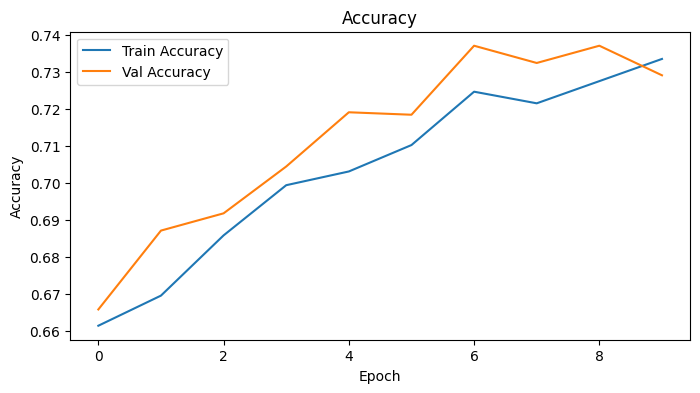

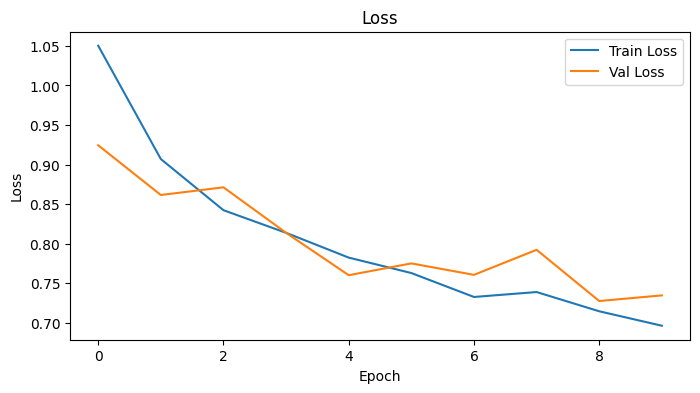

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/Projects/skin_care/efficientnetV2B0_feature_extract_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 90 variables whereas the saved optimizer has 94 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.evaluate(test_ds)

47/47 ━━━━━━━━━━━━━━━━━━━━ 277s 5s/step - accuracy: 0.7686 - loss: 0.6914


[0.6841565370559692, 0.7618097066879272]

In [ ]:
import tensorflow as tf

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224, scale=True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into
  (224, 224, 3).

  Parameters
  ----------
  filename (str): string filename of target image
  img_shape (int): size to resize target image to, default 224
  scale (bool): whether to scale pixel values to range(0, 1), default True
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.image.decode_jpeg(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    # Rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
def pred_and_plot(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get the predicted class
  if len(pred[0]) > 1: # check for multi-class
    pred_class = class_names[pred.argmax()] # if more than one output, take the max
  else:
    pred_class = class_names[int(tf.round(pred)[0][0])] # if only one output, round

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

## Calculating accuracy, precision, F1-score

In [ ]:

import numpy as np
y_true = []
y_pred = []
for batch_x, batch_y in test_ds:
  preds = model.predict(batch_x, verbose=0)
  y_pred.extend(np.argmax(preds, axis=1))
  y_true.extend(batch_y.numpy())
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
y_true_indices = np.argmax(y_true, axis=1)
y_true_indices == y_pred

array([ True, False,  True, ...,  True,  True, False])

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):
  """
  Calculates model accuracy, precision, recall and f1 score of a binary classification model.

  Args:
      y_true: true labels in the form of a 1D array
      y_pred: predicted labels in the form of a 1D array

  Returns a dictionary of accuracy, precision, recall, f1-score.
  """
  # Calculate model accuracy
  model_accuracy = accuracy_score(y_true, y_pred) * 100
  # Calculate model precision, recall and f1 score using "weighted average
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
  model_results = {"accuracy": model_accuracy,
                  "precision": model_precision,
                  "recall": model_recall,
                  "f1": model_f1}
  return model_results


In [ ]:
calculate_results(y_true_indices, y_pred)

{'accuracy': 76.18097139055223,
 'precision': 0.7449240756836092,
 'recall': 0.7618097139055223,
 'f1': 0.7388916357331491}

# Task
Display 8 randomly selected images from the `test_ds` dataset. For each image, show its true class and the model's predicted class with its confidence score, using the `class_names` mapping.

## Extract Test Images and Labels

### Subtask:
Extract all images and their corresponding true labels from the `test_ds` dataset into NumPy arrays or lists for easier sampling.


**Reasoning**:
The first step is to initialize empty lists to store the images and labels extracted from the `test_ds` dataset.



In [ ]:
test_images_list = []
test_labels_list = []

print("Initialized empty lists for test images and labels.")

Initialized empty lists for test images and labels.


**Reasoning**:
Iterate through the `test_ds` dataset to extract image tensors and one-hot encoded label tensors, appending them to the initialized lists. Then, convert these lists into single NumPy arrays and transform the one-hot encoded labels into class indices.



In [ ]:
for images, labels in test_ds:
    test_images_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

test_images = np.concatenate(test_images_list, axis=0)
test_labels = np.concatenate(test_labels_list, axis=0)
test_true_labels_indices = np.argmax(test_labels, axis=1)

print(f"Extracted {test_images.shape[0]} images with shape {test_images.shape[1:]} and {test_true_labels_indices.shape[0]} labels.")
print(f"Example of first 5 true label indices: {test_true_labels_indices[:5]}")

Extracted 1503 images with shape (224, 224, 3) and 1503 labels.
Example of first 5 true label indices: [5 1 5 4 6]


## Select Random Images

### Subtask:
Randomly select 8 images and their true labels from the extracted test data.


**Reasoning**:
To randomly select 8 images and their corresponding true labels, I will generate 8 unique random indices, and then use these indices to pick elements from the `test_images` and `test_true_labels_indices` arrays respectively.



In [ ]:
import numpy as np

num_test_images = test_images.shape[0]
random_indices = np.random.choice(num_test_images, size=8, replace=False)

selected_test_images = test_images[random_indices]
selected_true_labels = test_true_labels_indices[random_indices]

print(f"Selected {len(selected_test_images)} random test images and their true labels.")
print(f"Shape of selected images: {selected_test_images.shape}")
print(f"Selected true labels (indices): {selected_true_labels}")

Selected 8 random test images and their true labels.
Shape of selected images: (8, 224, 224, 3)
Selected true labels (indices): [4 5 6 5 3 5 5 5]


**Reasoning**:
With the random images and true labels selected, the next step is to make predictions on these selected images using the pre-trained model. This will provide the necessary predicted class probabilities for plotting later.



In [ ]:
selected_predictions = model.predict(selected_test_images)
predicted_class_indices = np.argmax(selected_predictions, axis=1)
predicted_confidences = np.max(selected_predictions, axis=1)

print(f"Predictions made for {len(selected_predictions)} selected images.")
print(f"Predicted class indices: {predicted_class_indices}")
print(f"Predicted confidences: {predicted_confidences}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predictions made for 8 selected images.
Predicted class indices: [5 5 5 5 3 5 4 5]
Predicted confidences: [0.8520974  0.71571994 0.9138661  0.99324036 0.7417917  0.99539727
 0.55416065 0.5915213 ]


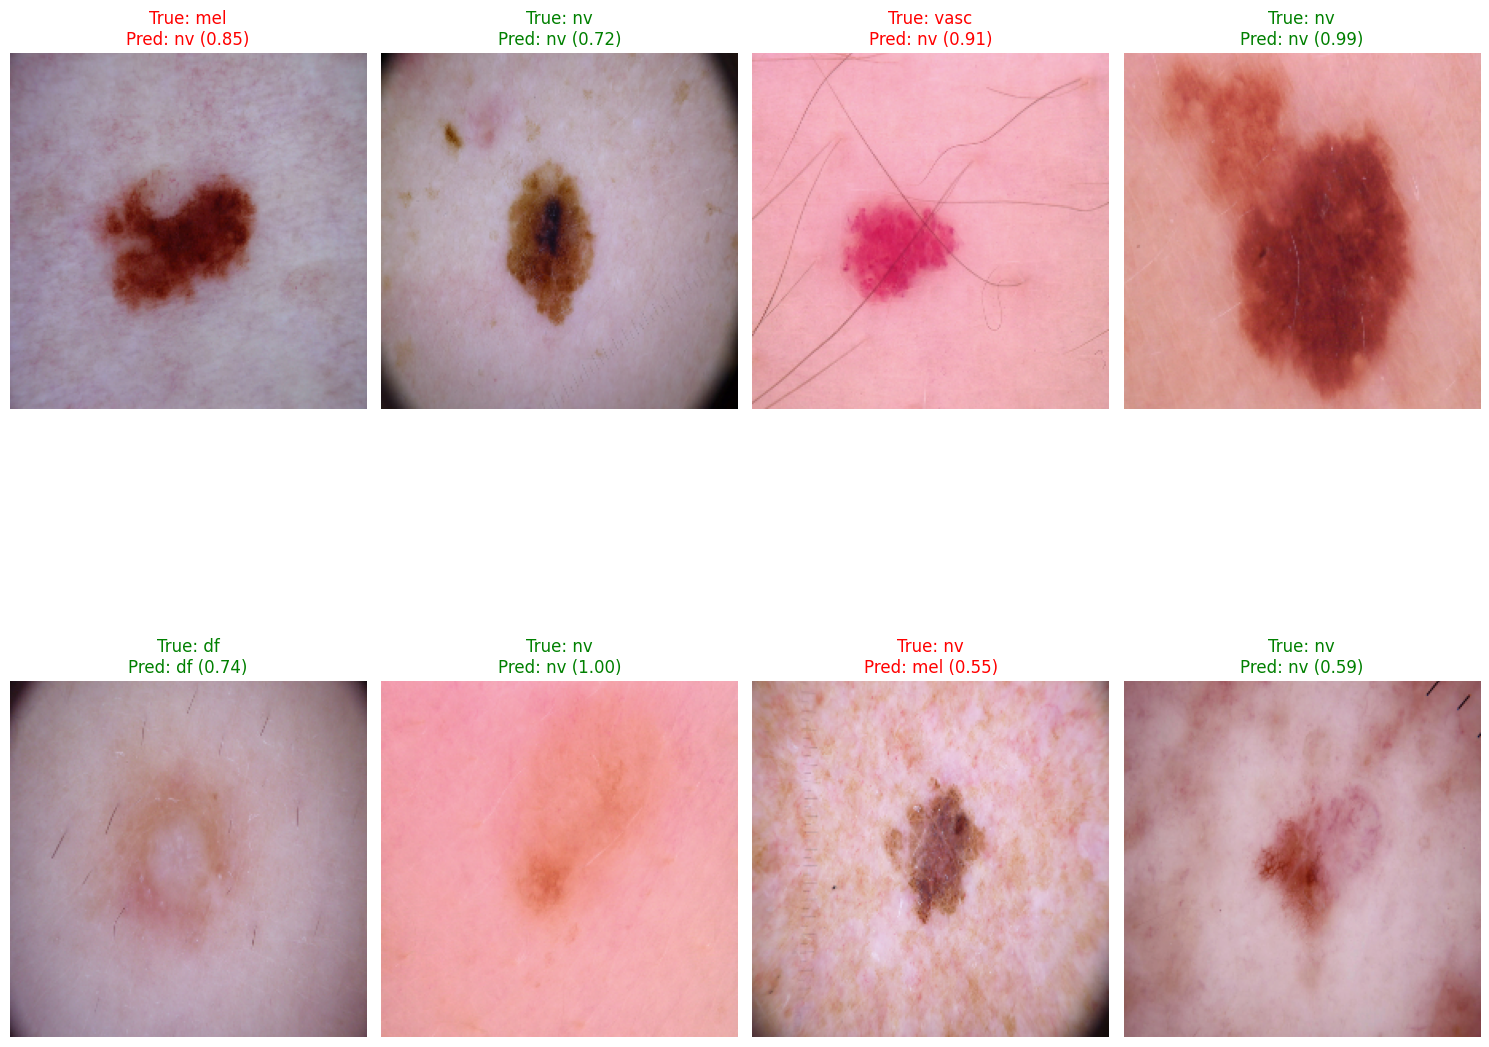

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(selected_test_images[i].astype('uint8')) # Ensure image data type is suitable for imshow
    true_label = class_names[selected_true_labels[i]]
    predicted_label = class_names[predicted_class_indices[i]]
    confidence = predicted_confidences[i]

    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label} ({confidence:.2f})", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()
